<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_S5_Pipeline_Housing_(SV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ✏️ Ejercicio 5.1 — Pipeline para Housing (DESAFÍO)

Construí un pipeline completo para el dataset Housing:

1. Identificá las columnas numéricas
2. Elegí la estrategia de imputación adecuada
3. Elegí el scaler apropiado para cada columna (pensá en las distribuciones)
4. No hay variables categóricas en Housing — simplificá el ColumnTransformer
5. Dividí en train/test y aplicá el pipeline

**Variable objetivo:** `median_house_value`

In [91]:
#Setup — importar librerías y cargar datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  ## librería estadística - computación científica

#importación de las librerías
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, OrdinalEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (12, 4)
sns.set_theme(style='whitegrid', palette='Set2')

print('Setup completo ✓')

Setup completo ✓


In [92]:
# ── Dataset 2: California Housing ───────────────────────────────────────
# Dataset de precios de viviendas con valores faltantes y outliers reales
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing(as_frame=True)
housing = housing_data.frame.copy()
housing.columns = [c.lower() for c in housing.columns]

# Introducir nulos artificialmente para practicar (como en la realidad)
rng = np.random.default_rng(42)
idx_nulos = rng.choice(housing.index, size=500, replace=False)
housing.loc[idx_nulos[:300], 'total_bedrooms'] = np.nan
housing.loc[idx_nulos[300:], 'population']     = np.nan

# muestra cantidad de filas y columnas
print(f'Housing:  {housing.shape}')

Housing:  (20640, 10)


In [93]:
housing.head()

,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude,medhouseval,total_bedrooms
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,NaN
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,NaN
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,NaN
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,NaN
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,NaN


In [94]:
# Diagnóstico inicia de valores faltantes
def diagnostico_nulos(df, nombre='Dataset'):
    '''Muestra un resumen de valores nulos por columna.'''
    nulos = df.isnull().sum()
    pct   = (df.isnull().mean() * 100).round(1)
    resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
    resumen = resumen[resumen['Nulos'] > 0].sort_values('Nulos', ascending=False)
    print(f'--- {nombre} — columnas con valores faltantes ---')
    if len(resumen) == 0:
        print('  Sin valores faltantes.')
    else:
        print(resumen.to_string())
    print(f'  Total filas: {len(df)}')
    print()

diagnostico_nulos(housing, 'Housing')

--- Housing — columnas con valores faltantes ---
                Nulos  Porcentaje (%)
total_bedrooms  20640           100.0
population        200             1.0
  Total filas: 20640



In [95]:
# TODO: Pipeline completo para Housing variable 'medhouseval'
housing_model = housing.copy()

# Eliminar columnas no útiles, que generalmente no aportan valor predictivo al modelo.
# Also remove 'total_bedrooms' as it's 100% null and cannot be imputed.
housing_model.drop(columns=['medinc', 'population', 'total_bedrooms'], inplace=True)

# Variable objetivo
X_h = housing_model.drop(columns=['medhouseval']) #variables predictoras"
y_h = housing_model['medhouseval']

# 1. Split train/test - ANTES del preprocesamiento
# X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(...)
# Divide los datos en: 80% entrenamiento y 20% prueba
# Parámetros test_size=0.2 - Reserva el 20% para evaluación.
# random_state=42 - Hace que la división sea reproducible en la misma partición.
# stratify=y - Mantiene igual porcentajes en train y test.

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42)

num_cols = housing_model.select_dtypes(include='number').columns.tolist()
#print('Columnas numéricas num_cols:\n', num_cols)

# 2. Pipeline numérico (todas las columnas son numéricas)
# Elegí la estrategia de imputación adecuada
housing_pipeline = Pipeline([
     ('imputer', SimpleImputer(strategy='median')),
     ('scaler',  RobustScaler())
 ])

# 3. Ajustar y transformar
housing_pipeline.fit(X_h_train)
X_h_train_proc = housing_pipeline.transform(X_h_train)
X_h_test_proc  = housing_pipeline.transform(X_h_test)

# 4. Verificar
print(f'Train: {X_h_train.shape} | Test: {X_h_test.shape}')
#print('Columnas:\n', X_h_train.columns.tolist())
print('Nulos restantes:', pd.DataFrame(X_h_train_proc).isnull().any().any())
print('\n✓ Pipeline completo. Dataset listo para modelado. FIN')

Train: (16512, 6) | Test: (4128, 6)
Nulos restantes: False

✓ Pipeline completo. Dataset listo para modelado. FIN


In [96]:
# Verificar resultado: estadísticas del training procesado
print('----- Estadísticas del dataset procesado -----')
X_h_train_proc_df = pd.DataFrame(X_h_train_proc, columns=X_h_train.columns)
X_h_train_proc_df.describe()

----- Estadísticas del dataset procesado -----


,houseage,averooms,avebedrms,aveoccup,latitude,longitude
count,16512.000000,1.651200e+04,16512.000000,16512.000000,16512.000000,16512.000000
mean,-0.020617,1.239053e-01,0.505107,0.328620,0.364947,-0.282182
std,0.663289,1.483780e+00,4.616526,13.602830,0.563764,0.527804
min,-1.473684,-2.701699e+00,-7.629503,-2.496392,-0.451187,-1.536842
25%,-0.578947,-4.871520e-01,-0.455861,-0.456344,-0.087071,-0.868421
50%,0.000000,-2.760040e-16,0.000000,0.000000,0.000000,0.000000
75%,0.421053,5.128480e-01,0.544139,0.543656,0.912929,0.131579
max,1.210526,8.494391e+01,262.010771,1457.371361,2.029024,1.105263


# **Extras**

## Descripción y Clasificación de las Variables del Dataset `housing`

In [97]:
print('--- Resumen de Tipos de Datos, Categorías y Naturaleza de Variables ---\n')
for col in housing.columns:
    print(f"Columna: {col}")
    print(f"  Tipo de Dato: {housing[col].dtype}")
    if housing[col].dtype in ['float64', 'int64']:
        print(f"  Categoría: Numérica")
        if housing[col].nunique() < 50 and housing[col].dtype == 'int64': # Heuristic to guess discrete numerical
            print(f"  Naturaleza: Numérica Discreta (pocos valores únicos, como la edad de la casa en años).")
        else:
            print(f"  Naturaleza: Numérica Continua (valores con muchos decimales o rango amplio).")

        # Specific descriptions for each numerical column
        if col == 'medinc':
            print("    - Ingreso promedio en el bloque de casas (en decenas de miles de dólares). Afecta directamente el valor de la vivienda.")
        elif col == 'houseage':
            print("    - Edad promedio de las casas en el bloque. Las casas más antiguas/nuevas pueden tener diferentes valores.")
        elif col == 'averooms':
            print("    - Número promedio de habitaciones por casa. Un factor clave en el tamaño y valor de la propiedad.")
        elif col == 'avebedrms':
            print("    - Número promedio de dormitorios por casa. Relacionado con el tamaño y la funcionalidad del hogar.")
        elif col == 'population':
            print("    - Población del bloque de casas. Puede indicar densidad y demanda en la zona. *Contiene nulos artificiales.*")
        elif col == 'aveoccup':
            print("    - Ocupación promedio del hogar (personas por hogar). Relacionado con la densidad de uso del espacio.")
        elif col == 'latitude':
            print("    - Latitud geográfica del bloque de casas. Ubicación importante para el precio.")
        elif col == 'longitude':
            print("    - Longitud geográfica del bloque de casas. Ubicación importante para el precio.")
        elif col == 'medhouseval':
            print("    - Valor medio de la casa (en cientos de miles de dólares) para el bloque. **Variable Objetivo**.")
        elif col == 'total_bedrooms':
            print("    - Número total de dormitorios en el bloque de casas. Relacionado con el tamaño de las propiedades. *Contiene nulos artificiales y reales.*")
    else:
        print(f"  Categoría: Categórica (no se esperan en este dataset según el enunciado)")
        print(f"  Naturaleza: Variable con valores discretos no numéricos que representan categorías o etiquetas.")

    null_count = housing[col].isnull().sum()
    if null_count > 0:
        print(f"  Valores Faltantes: Sí, {null_count} ({round(null_count / len(housing) * 100, 2)}%)")
    else:
        print("  Valores Faltantes: No")
    print('\n')

print('--- Estadísticas Descriptivas para Columnas Numéricas ---')
display(housing.describe())

--- Resumen de Tipos de Datos, Categorías y Naturaleza de Variables ---

Columna: medinc
  Tipo de Dato: float64
  Categoría: Numérica
  Naturaleza: Numérica Continua (valores con muchos decimales o rango amplio).
    - Ingreso promedio en el bloque de casas (en decenas de miles de dólares). Afecta directamente el valor de la vivienda.
  Valores Faltantes: No


Columna: houseage
  Tipo de Dato: float64
  Categoría: Numérica
  Naturaleza: Numérica Continua (valores con muchos decimales o rango amplio).
    - Edad promedio de las casas en el bloque. Las casas más antiguas/nuevas pueden tener diferentes valores.
  Valores Faltantes: No


Columna: averooms
  Tipo de Dato: float64
  Categoría: Numérica
  Naturaleza: Numérica Continua (valores con muchos decimales o rango amplio).
    - Número promedio de habitaciones por casa. Un factor clave en el tamaño y valor de la propiedad.
  Valores Faltantes: No


Columna: avebedrms
  Tipo de Dato: float64
  Categoría: Numérica
  Naturaleza: Numéric

,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude,medhouseval,total_bedrooms
count,20640.000000,20640.000000,20640.000000,20640.000000,20440.000000,20640.000000,20640.000000,20640.000000,20640.000000,0.0
mean,3.870671,28.639486,5.429000,1.096675,1425.387769,3.070655,35.631861,-119.569704,2.068558,NaN
std,1.899822,12.585558,2.474173,0.473911,1132.209068,10.386050,2.135952,2.003532,1.153956,NaN
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990,NaN
25%,2.563400,18.000000,4.440716,1.006079,786.000000,2.429741,33.930000,-121.800000,1.196000,NaN
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000,NaN
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250,NaN
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010,NaN


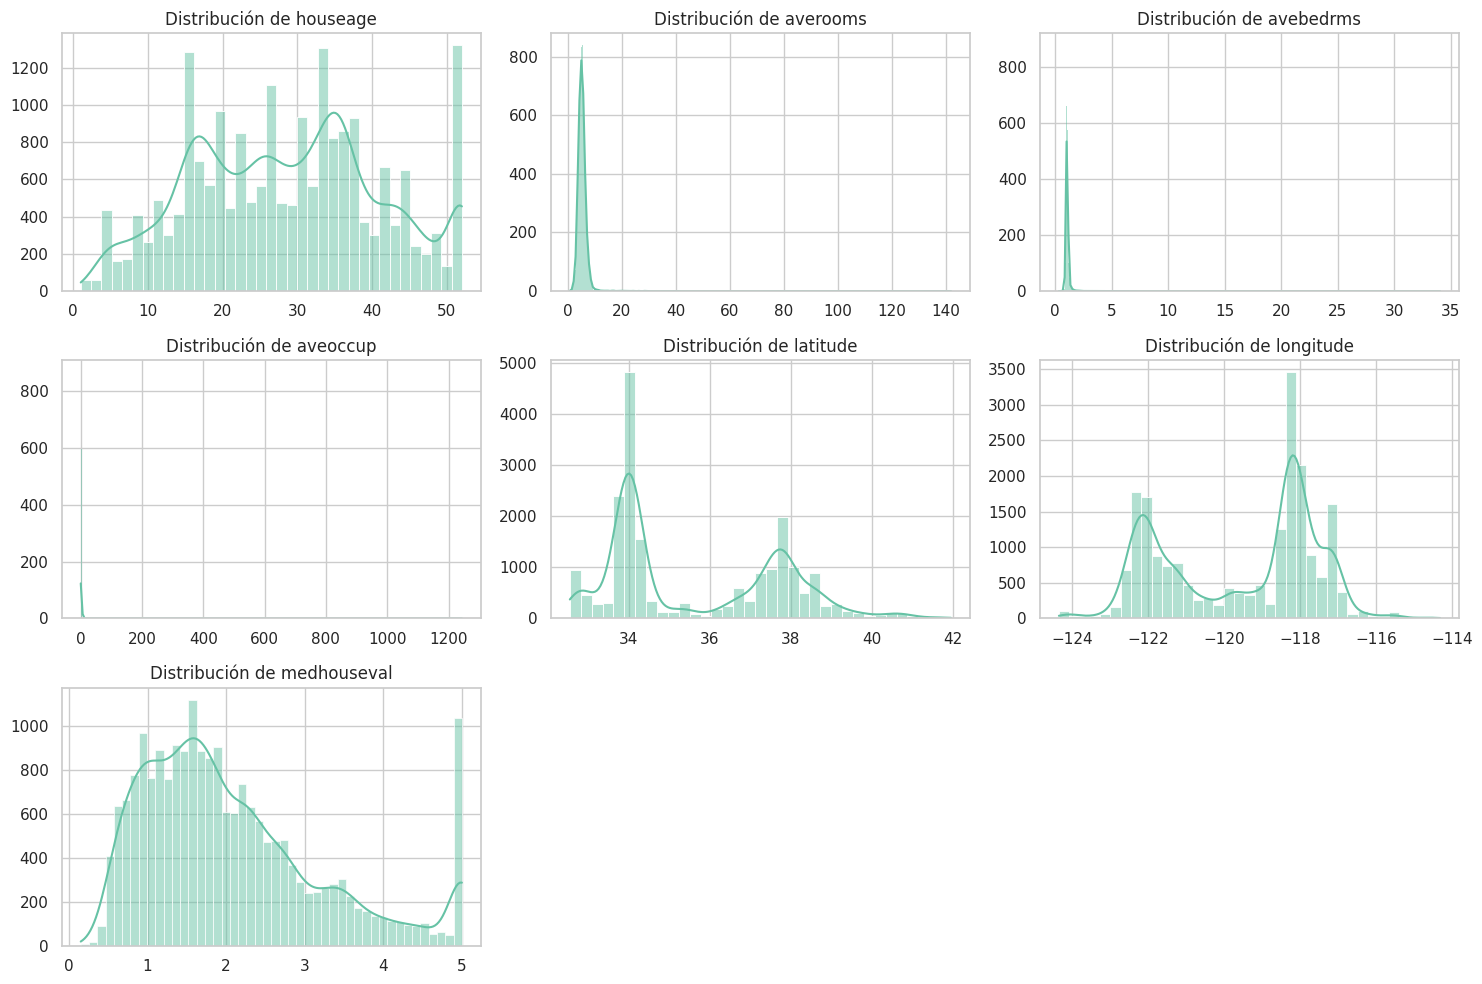

In [98]:
# Visualización de la distribución de cada variable numérica

plt.figure(figsize=(15, 10))
for i, col in enumerate(housing_model.columns):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    sns.histplot(housing_model[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [99]:
# Verificar resultado: estadísticas del housing_model
print('----- Estadísticas del dataset original -----')
housing_model_df = pd.DataFrame(housing_model, columns=housing_model.columns)
housing_model_df.describe()

----- Estadísticas del dataset original -----


,houseage,averooms,avebedrms,aveoccup,latitude,longitude,medhouseval
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,5.429000,1.096675,3.070655,35.631861,-119.569704,2.068558
std,12.585558,2.474173,0.473911,10.386050,2.135952,2.003532,1.153956
min,1.000000,0.846154,0.333333,0.692308,32.540000,-124.350000,0.149990
25%,18.000000,4.440716,1.006079,2.429741,33.930000,-121.800000,1.196000
50%,29.000000,5.229129,1.048780,2.818116,34.260000,-118.490000,1.797000
75%,37.000000,6.052381,1.099526,3.282261,37.710000,-118.010000,2.647250
max,52.000000,141.909091,34.066667,1243.333333,41.950000,-114.310000,5.000010
